In [82]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
fake_df = pd.read_csv("Fake.csv",engine="python",on_bad_lines="skip")
true_df = pd.read_csv("True.csv",engine="python",on_bad_lines="skip")

In [45]:
fake_sample = fake_df.sample(2500, random_state=42)

true_sample = true_df.sample(2500, random_state=42)
df = pd.concat([fake_sample, true_sample], axis=0)
df = df.sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)

print("\nDataset Shape:", df.shape)


Dataset Shape: (5000, 5)


In [62]:
fake_df["label"] = 0
true_df["label"] = 1

In [63]:
fake_sample = fake_df.sample(3000, random_state=42)
true_sample = true_df.sample(3000, random_state=42)

df = pd.concat([fake_sample, true_sample])
df = df.sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)

In [64]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

df["content"] = df["title"] + " " + df["text"]

In [65]:
def clean_text(text):

    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)
    return text.strip()
df["content"] = df["content"].apply(clean_text)

In [66]:
X = df["content"]
y = df["label"]

In [67]:
vectorizer = TfidfVectorizer(stop_words='english',max_features=5000)
X = vectorizer.fit_transform(X)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [69]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [70]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9741666666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       614
           1       0.96      0.98      0.97       586

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



In [71]:
def predict_news(news):

    news = clean_text(news)
    vector_input = vectorizer.transform([news])
    prediction = model.predict(vector_input)

    if prediction[0] == 0:
        return "FAKE NEWS"

    else:
        return "REAL NEWS"

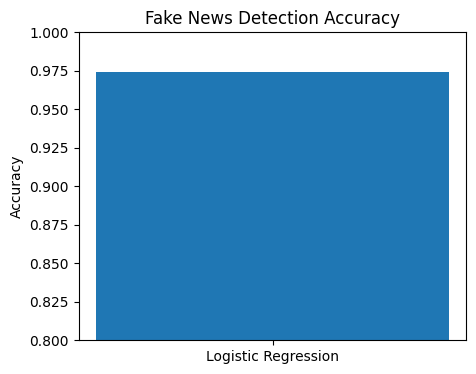

In [73]:
plt.figure(figsize=(5,4))

plt.bar(["Logistic Regression"], [accuracy])
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("Fake News Detection Accuracy")
plt.show()

In [75]:
sample_news = """
NASA launched a new satellite to study climate change.
"""
print("\nSample Prediction:")
print(predict_news(sample_news))


Sample Prediction:
FAKE NEWS


In [81]:
user_news = input("\nEnter News Text:\n")
print("\nPrediction:")
print(predict_news(user_news))


Enter News Text:
 The health ministry started a vaccination campaign to prevent seasonal diseases.



Prediction:
REAL NEWS
